# Sprint 18 - Redes Neuronales (Ejercicios)

En estos ejercicios adicionales continuamos con lo visto en el documento **S18_Redes_Neuronales_Sesiones**, y vamos a aprender un poco más sobre el funcionamiento detrás de las **redes neuronales**, junto con otras técnicas que nos permitan optimizar su rendimiento. Para ello, continuamos trabajando con los archivos de audio de la base de datos **RAVDESS**, y los datos de prueba procesados y guardados previamente. Si necesitas acceder a ellos directamente puedes utilizar siguientes links:

* Atributos de prueba: [X_test.csv](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/X_test.csv).
* Variable objetivo de prueba [y_test](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/y_test.csv).

En un primer momento, nos enfocaremos en el mejoramiento de modelos basados en **redes neuronales** mediante la técnica de **Aumento de datos**. Una dificultad importante cuando se trabaja con información cuyo costo de adquisición es alto (como son los audios), radica en la falta de observaciones suficientes y diversas para entrenar algoritmos predictivos. En este sentido, existen mecanismos robustos que permiten simular registros mediante la aplicación de distorsiones leves a los datos originales, logrando así aumentar la fuente de información base para dicho entrenamiento.

A continuación, estudiaremos en detalle lo que sucede en las primeras capas de nuestro modelo de mejor rendimiento: la **convolucional** y la de **activación** con función ReLu. Para esto, extraeremos información que no siempre se visualiza en el desarrollo de proyectos de ciencia de datos, pero que nos permita a nosotros como desarrolladores del modelo, profundizar en el entendimiento de estas estructuras y lo que generan como salida.   

## Optimización con aumento de datos

### Ejercicio 1

Importa todo lo necesario desde **pandas**, **numpy**, **matplotlib**, **re**, **warnings**, **kasgglehub**, **glob**, **librosa**, **IPython.display**, **Scikit-Learn** y **tensorflow.keras**, y que nos permita trabajar con archivos de audio y modelos de redes neuronales. 

In [1]:
# Cargar librerias para manipular datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings(action = "ignore")

# Cargar librerias para modelamiento
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Cargar librerias para carga de archivos de audio
import kagglehub
from glob import glob

# Cargar librerias para tratar audios
import librosa
import IPython.display as ipd

# Cargar librerías para construir redes neuronales
from tensorflow.keras import models, Input, layers, optimizers, utils

Importa los archivos de audio desde Kaggle y genera una lista con sus nombres.  

In [2]:
# Importar archivos de audio y guardar ruta
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

# Crear lista de archivos tipo wav
audio_files = glob(f"{path}/*/*.wav")
print(f"Archivos totales: {len(audio_files):,.0f}")
print()
print(f"Ejemplos de nombre de archivo:\n{re.search("[\w-]*.wav",audio_files[0])[0]}\n{re.search("[\w-]*.wav",audio_files[100])[0]}")

Archivos totales: 1,440

Ejemplos de nombre de archivo:
03-01-01-01-01-01-01.wav
03-01-06-02-01-01-02.wav


### Ejercicio 2

Carga un archivo de audio de ejemplo, digamos aquel en la posición 100 de la lista. Establece por defecto una duración de 3 segundos y un offset de 0.5 segundos.

In [3]:
signal, sr = librosa.load(
    audio_files[100], 
    duration  = 3, 
    offset = 0.5
)
ipd.Audio(signal, rate = sr)

Modifica la señal incrementando su velocidad mediante la función `librosa.effects.time_stretch` con el argumento `rate = 1.5`. Guarda el resultado en una nueva variable.

In [4]:
signal_mod = librosa.effects.time_stretch(signal, rate = 1.5)
ipd.Audio(signal_mod, rate = sr)

Cambia ahora la frecuencia o tonalidad de la señal mediante la función `librosa.effects.pitch_shift` con el argumento `n_steps = -5`.

In [5]:
signal_mod = librosa.effects.pitch_shift(signal_mod, sr = sr, n_steps = -5)
ipd.Audio(signal_mod, rate = sr)

Utiliza la siguiente función para distorsionar aún más la señal incorporando *ruido blanco*:

```py
def func_ruido (signal, intensidad = 0.01):
    noise = np.random.randn(len(signal))
    s_noise = signal + intensidad * noise
    return s_noise
```

In [6]:
# Crear funcion para incorporar ruido blanco
def func_ruido (signal, intensidad = 0.01):
    noise = np.random.randn(len(signal))
    s_noise = signal + intensidad * noise
    return s_noise

# Incorporar ruido en sonido
signal_mod = func_ruido(signal_mod)
ipd.Audio(signal_mod, rate = sr)

Como ves, has aplicado 3 distorsiones a un audio: incremento de la velocidad, cambio de tonalidad e inclusión de ruido ambiental. Aplica entonces estas distorsiones a cualquier señal de audio original. Para esto, crea una función que tome una señal como entrada y la acelere a una tasa aleatoria entre 1 y 1.01, incremente su frecuencia en una cantidad aleatoria de pasos entre -0.5 y 0.5, e incorpore ruido blanco con una instensidad de 0.0001.

In [7]:
# Crear funcion para distorsionar sonido
def func_distorsion (s, sr):

    # Acelerar sonido
    s = librosa.effects.time_stretch(
        s, 
        rate = 1 + np.random.rand() * 0.01
    )

    # Cambiar frecuencia
    s = librosa.effects.pitch_shift(
        s, 
        sr = sr, 
        n_steps = -0.5 + np.random.rand() * 1
    )

    # Agregar ruido blanco
    s = func_ruido(
        s, 
        intensidad = 0.0001
    )

    return s

In [8]:
# Verificar funcionamiento de la funcion
signal_dist = func_distorsion(signal, sr)
ipd.Audio(signal_dist, rate = sr)

### Ejercicio 3

Utiliza un bucle para aplicar distorsiones a todos los archivos de audio de **RAVDESS** mediante la función creada. Guarda tus resultados en una variable nueva de tipo lista.

In [9]:
audio_dist = []

for i in range(len(audio_files)):
    
    # Extraer sonido
    signal, sr = librosa.load(
        audio_files[i], 
        duration  = 3, 
        offset = 0.5
    )

    # Aplicar distorsion
    signal_dist = func_distorsion(signal, sr)

    # Guardar resultado
    audio_dist.append(signal_dist)

print(f"# de archivos distorsionados: {len(audio_dist):,.0f}")

# de archivos distorsionados: 1,440


Utiliza otro bucle para guardar en otra lista todas las señales de audio originales.

In [10]:
audio_orig = []

for i in range(len(audio_files)):

    # Extraer sonido
    sound, sr = librosa.load(
        audio_files[i], 
        duration  = 3, 
        offset = 0.5
    )

    # Guardar resultado
    audio_orig.append(sound)

print(f"# de archivos originales: {len(audio_orig):,.0f}")

# de archivos originales: 1,440


Concatena la lista de señales distorsionadas con aquella de originales y guarda el resultado en una variable.

In [11]:
audio_all = audio_orig + audio_dist
print(f"# de archivos totales: {len(audio_all):,.0f}")

# de archivos totales: 2,880


### Ejercicio 4

Ya tenemos nuestra simulación que nos permitido duplicar la cantidad de datos. Es necesario ahora transformar estas observaciones a fin de poder utilizarlas en el modelo basado en redes neuronales. Haslo de tal forma que se genere un dataset con 130 atributos, donde cada atributo represente los decibeles promedio en una unidad de tiempo generada por una Transformada de Fourier.

In [12]:
# Crear funcion para transformar datos de audio a decibeles
def func_transaudio (signal):

    signal_ft = np.abs(librosa.stft(signal).real)
    signal_db = librosa.amplitude_to_db(signal_ft, ref = 0)
    obs = signal_db.mean(axis = 0)

    db_min = min(obs)
    if len(obs) < 130:
        obs = np.append(obs,[db_min] * (130 - len(obs)))

    return obs

In [13]:
# Aplicar funcion para tabular archivos de audio
data_audio = []
for i in range(len(audio_all)):
    data_audio.append(func_transaudio(audio_all[i]))

data_audio = np.array(data_audio)

# Convertir a dataframe
df_audio = pd.DataFrame(
    data_audio,
    columns = ["t" + str(x+1) for x in range(data_audio.shape[1])]
)
df_audio.shape

(2880, 130)

A partir del nombre de los archivos de audio, extrae la variable objetivo, una variable que indique si la intensidad es alta y una variable buleana que indique si el actor es hombre. Asegúrate que la variable objetivo tome valores entre 0 y 7 (representativos de las 8 emociones).

In [14]:
# Extraer todos las caracteristicas de los nombres de archivos
codificacion = []
for a in audio_files:
    codnum = re.search("[0-9]{2}-[0-9]{2}-[0-9]{2}-[0-9]{2}-[0-9]{2}-[0-9]{2}-[0-9]{2}", a)
    codificacion.append(codnum.group().split("-"))

df_codificacion = pd.DataFrame(
    codificacion,
    columns = ["tipo","canal","emocion","intensidad","frase","num_repeticion","id_actor"]
)

# Mantener solamente caracteristicas relevantes
df_codificacion = df_codificacion.drop(columns = ["tipo", "canal", "frase", "num_repeticion"])

# Cambiar los valores de la variable objetivo
df_codificacion["emocion"] = df_codificacion["emocion"].astype(int) - 1

# Cambiar los valores de intensidad la variable de intensidad
df_codificacion["intensidad"] = df_codificacion["intensidad"].astype(int) - 1
df_codificacion = df_codificacion.rename(columns = {"intensidad": "intensidad_alta"})

# Sustituir variable de id del actor por una que indique si la persona es hommbre
df_codificacion["es_hombre"] = df_codificacion["id_actor"].astype(int).apply(lambda x: 1 if x%2 == 1 else 0)
df_codificacion = df_codificacion.drop(columns = "id_actor")

# Duplicar caracteristicas dado el aumento de datos
df_codificacion = pd.concat([df_codificacion, df_codificacion])
df_codificacion = df_codificacion.reset_index(drop = True)
df_codificacion.shape

(2880, 3)

Une finalmente estas caracteristicas con la información transformada de las señales de audio.

In [15]:
df_audio = pd.concat(
    [df_audio, df_codificacion],
    axis = 1
)
df_audio.shape

(2880, 133)

### Ejercicio 5

Ejecuta con estos datos los siguientes procesos de ingeniería:

* Separa la variable objetivo de los atributos.
* Escala los atributos con el método de normalización.
* Particiona el dataset aplicando un estado randómico para garantizar la replicabilidad y garantizando que el subconjunto de prueba represente el 20% del total de observaciones.

In [16]:
# Separar atributos de variable objetivo
X = df_audio.drop(columns = "emocion")
y = df_audio["emocion"]

In [17]:
# Escalar atributos mediante normalizacion
mod_esc = MinMaxScaler()
mod_esc.fit(X)

X = pd.DataFrame(
    mod_esc.transform(X),
    columns = X.columns
)

In [18]:
# Particionar dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2, 
    random_state = 123
)
print(X_train.shape)
print(X_test.shape)

(2304, 132)
(576, 132)


A fin de hacer que los resultados a continuación sean comparables con lo que ya hemos venido trabajando previamente, sustituye el subconjunto de prueba por aquellos guardados y utilizados para evaluar el modelo de mejor rendimiento antes desarrollado.

In [19]:
X_test = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/X_test.csv")
y_test = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/y_test.csv")
y_test = y_test["emocion"]

### Ejercicio 6

Veamos si el **aumento de datos** que hicimos incrementa la asertividad del modelo. Si recuerdas, nuestro modelo de **red neuronal** fue desarrollado con la siguiente arquitectura:

```py
# Crear modelo 
utils.set_random_seed(111)
modelo = models.Sequential(name = "Convolucional")

# Configurar arquitectura
modelo.add(Input(shape = (X_train.shape[1],1)))
modelo.add(layers.Conv1D(
    filters = 5, 
    kernel_size = 10, 
    strides = 1, 
    padding = "same"
))
modelo.add(layers.Activation("relu"))
modelo.add(layers.Dropout(rate = 0.1))
modelo.add(layers.MaxPooling1D(
    pool_size = 10, 
    strides = 2, 
    padding = "valid"
))
modelo.add(layers.Dropout(rate = 0.1))
modelo.add(layers.Flatten())
modelo.add(layers.Dense(units = len(y.unique())))
modelo.add(layers.Activation("softmax"))

modelo.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = optimizers.Adam(learning_rate = 0.001),
    metrics = ["acc"]
)
```

Una vez configurado, se lo entrenó con 250 iteraciones de **retropropagación**, y su resultado a nivel de exactitud alcanzo un valor cercano pero menor a 60%. Entrena nuevamente este modelo, sólo que esta vez hazlo con los datos aumentados y con las mismas iteraciones antes descritas.

In [20]:
# Crear modelo 
utils.set_random_seed(111)
modelo = models.Sequential(name = "Convolucional")

# Configurar arquitectura
modelo.add(Input(shape = (X_train.shape[1],1)))
modelo.add(layers.Conv1D(
    filters = 5, 
    kernel_size = 10, 
    strides = 1, 
    padding = "same"
))
modelo.add(layers.Activation("relu"))
modelo.add(layers.Dropout(rate = 0.1))
modelo.add(layers.MaxPooling1D(
    pool_size = 10, 
    strides = 2, 
    padding = "valid"
))
modelo.add(layers.Dropout(rate = 0.1))
modelo.add(layers.Flatten())
modelo.add(layers.Dense(units = len(y.unique())))
modelo.add(layers.Activation("softmax"))

modelo.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = optimizers.Adam(learning_rate = 0.001),
    metrics = ["acc"]
)
modelo.summary()

Model: "Convolucional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 132, 5)         │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 132, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 132, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 62, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 310)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         2,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,543 (9.93 KB)

 Trainable params: 2,543 (9.93 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Entrenar el modelo
train_mod = modelo.fit(
    X_train,
    y_train,
    epochs = 250,
    validation_data = (X_test, y_test),
    verbose = 0
)

Evalúa el rendimiento alcanzado a fin de determinar si el **aumento de datos** ocasionó una mejoría.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


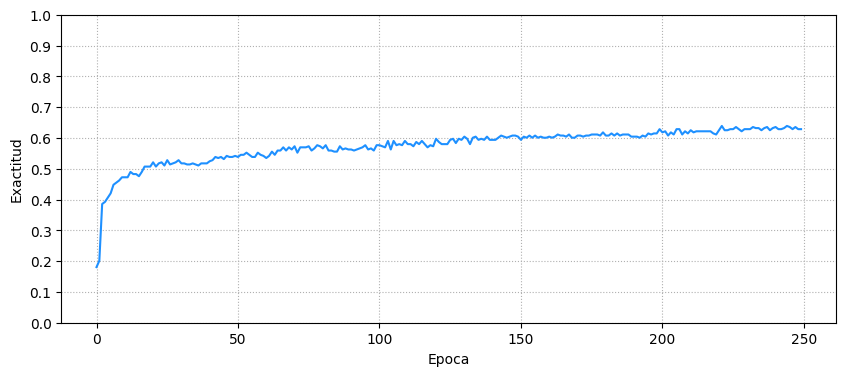

In [22]:
# Generar predicciones
y_pred = modelo.predict(X_test)
y_pred = [np.argmax(x) for x in y_pred]

# Visualizar evolución de exactitud
plt.figure(figsize = [10,4])
plt.plot(train_mod.history["val_acc"], color = "dodgerblue")
plt.xlabel("Epoca")
plt.ylabel("Exactitud")
plt.ylim([0,1])
plt.yticks(np.array(range(0,11))/10)
plt.grid(linestyle = ":")
plt.show()

In [23]:
# Crear matriz de confusion
pd.crosstab(
    index = y_test,
    columns = y_pred,
    rownames = ["Real"],
    colnames = ["Predicho"]
).style.background_gradient(cmap="Reds") 

Predicho,0,1,2,3,4,5,6,7
Real,,,,,,,,
0,11,4,1,0,0,1,0,0
1,1,24,2,2,0,0,2,0
2,2,0,16,0,3,8,2,10
3,1,5,1,19,0,2,2,6
4,0,0,1,0,39,1,3,2
5,0,1,5,0,6,13,0,5
6,2,2,3,4,5,0,29,2
7,1,0,1,0,3,3,2,30


In [24]:
# Crear reporte de clasificacion
print(metrics.classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

           0     0.6111    0.6471    0.6286        17
           1     0.6667    0.7742    0.7164        31
           2     0.5333    0.3902    0.4507        41
           3     0.7600    0.5278    0.6230        36
           4     0.6964    0.8478    0.7647        46
           5     0.4643    0.4333    0.4483        30
           6     0.7250    0.6170    0.6667        47
           7     0.5455    0.7500    0.6316        40

    accuracy                         0.6285       288
   macro avg     0.6253    0.6234    0.6162       288
weighted avg     0.6324    0.6285    0.6216       288



Con esta técnica de tratamiento de las señales de audio originales hemos logrado efectivamente un mejor rendimiento. Lo anterior se explica fácilmente en cuanto se han incorporado variaciones que han servido para que la **red neuronal** cuente con más información para identificar patrones relevantes que le permitan diferenciar emociones.

## Visualización y entendimiento de capas

### Ejercicio 1

Ya has aprendido que las **redes neuronales** están compuestas por una o varias capas, y a veces puede ser útil para nosotros como científicos de datos conocer un poco más cómo éstas funcionan internamente. Una forma de hacerlo es a través de la extracción de salidas intermedias generadas por las mismas. Tomemos entonces como referencia nuestro modelo mejorado por **aumento de datos**, de la cual debes consultar las capas que posee mediante el atributo `layers`.

In [25]:
modelo.layers

[<Conv1D name=conv1d, built=True>,
 <Activation name=activation, built=True>,
 <Dropout name=dropout, built=True>,
 <MaxPooling1D name=max_pooling1d, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Activation name=activation_1, built=True>]

Como puedes observar, para una correcta identificación de cada capa el modelo les signa un nombre, guarda entonces estos nombres en la lista `nombres_capas` utilizando el atributo `name`. 

In [26]:
nombres_capas = [x.name for x in modelo.layers]
nombres_capas

['conv1d',
 'activation',
 'dropout',
 'max_pooling1d',
 'dropout_1',
 'flatten',
 'dense',
 'activation_1']

Extraigamos la información de la capa convolucional. Haslo con el método `get_layer` del modelo, especificando como argumento `nombres_capas[0]`, y guarda el resultado en la variable `capa_conv`.

In [27]:
capa_conv = modelo.get_layer(nombres_capas[0])
capa_conv

<Conv1D name=conv1d, built=True>

Podemos crear un "submodelo" que considere únicamente esta capa convolucional a fin de estudiar qué es lo que predice por sí sola. Crea por tanto este submodelo con la función `models.Model` y especifica como argumentos de la función `inputs = capa_conv.input` y `outputs = capa_conv.output`.

In [28]:
submodelo = models.Model(
    inputs = capa_conv.input, 
    outputs = capa_conv.output, 
    name = f"Submodelo: {nombres_capas[0]}"
)
submodelo.summary()

Model: "Submodelo: conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 132, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 132, 5)         │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 2

Selecciona la observación 65 de los datos de prueba. Ajusta este registro con el método `values.reshape(1,132,1)` a fin que pueda servir de entrada para nuestro submodelo. 

In [29]:
# Extraer observacion
obs = 65
sound_orig = X_test.iloc[obs]

# Ajustar las dimensiones
sound_orig_input = sound_orig.values.reshape(1, 132, 1)

Procesa esta observación con el submodelo y genera la salida correspondiente. A esta última ajústala con el método `numpy().reshape(132,5)`. 

In [30]:
# Generar salidas del submodelo
salida = submodelo(sound_orig_input)

# Ajustar dimensiones de las salidas para mejor entendimiento de las mismas
salida = salida.numpy().reshape(132,5)
print("PRIMERAS 10 FILAS DE SALIDA GENERADA:")
print(salida[:10,:].round(4))

PRIMERAS 10 FILAS DE SALIDA GENERADA:
[[ 1.925e-01 -1.486e-01 -5.327e-01  3.435e-01 -2.709e-01]
 [-8.520e-02  5.420e-02 -5.889e-01  1.599e-01 -5.698e-01]
 [-1.280e-01  1.974e-01 -4.658e-01  8.140e-02 -4.591e-01]
 [-1.776e-01  7.780e-02 -1.957e-01 -5.700e-03 -1.910e-01]
 [-1.305e-01  9.930e-02  1.755e-01 -1.000e-04  1.568e-01]
 [-1.626e-01  1.024e-01  1.867e-01  1.810e-02  1.270e-01]
 [-1.743e-01  9.330e-02  1.835e-01 -7.900e-03  1.171e-01]
 [-1.784e-01  9.580e-02  1.960e-01 -2.400e-02  1.257e-01]
 [-1.800e-01  7.270e-02  2.212e-01 -2.890e-02  1.568e-01]
 [-1.680e-01  3.880e-02  2.454e-01 -1.330e-02  1.612e-01]]


Cada una de las columnas obtenidas representa la observación pasada por cada uno de los filtros establecidos en el submodelo. Visualiza las primeras 130 filas de estos resultados y compáralos con la observación original. Te recomiendo hacerlo mediante gráficos de línea.

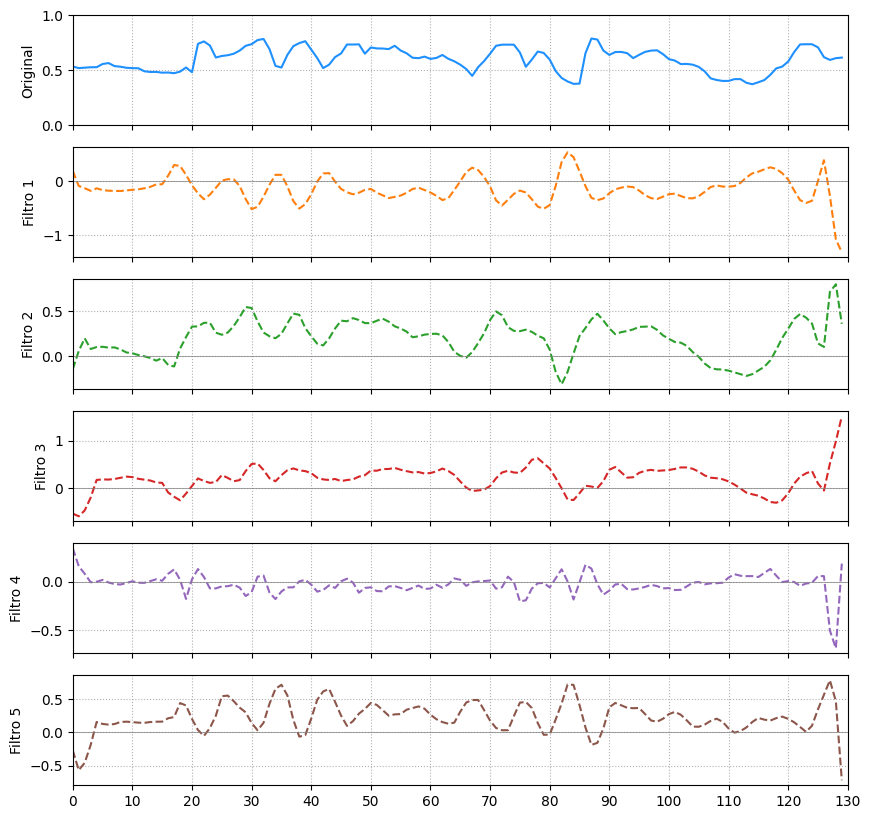

In [31]:
fig, ax = plt.subplots(6, 1, figsize = [10,10], squeeze = True, sharex = True)
ax[0].plot(sound_orig[:130], color = "dodgerblue")
ax[0].grid(linestyle = ":")
ax[0].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
ax[0].set_ylabel("Original")
ax[0].set_ylim([0,1])
ax[0].set_xlim([0,130])
for i in range(salida.shape[1]):
    filter_obs = salida[:,i]
    filter_obs = filter_obs[:130]
    ax[i + 1].plot(filter_obs, color = f"C{i + 1}", linestyle = "--")
    ax[i + 1].grid(linestyle = ":")
    ax[i + 1].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
    ax[i + 1].set_ylabel(f"Filtro {i + 1}")
    ax[i + 1].set_xlim([0,130])
    ax[i + 1].axhline(y = 0, linewidth = 0.5, color = "gray")
plt.show()

### Ejercicio 3

Queda la interrogante respecto a cómo surgieron estas salidas. A continuación intentaremos replicarlos de forma manual, y de esta manera poder comprender mejor que hace una capa convolucional. Para esto, inicia guardando los resultados de la salida generada por el primer filtro, estos es, la primera columna obtenida a partir de la capa convolucional.

In [32]:
salida_f1 = salida[:,0]

Extrae a continuación los pesos generados en la capa aplicando el método `get_weights` a `capa_conv`. Guarda en variables distintas aquellos pesos correspondientes al primer filtro (incluido el intercepto).

In [33]:
# Extraer todos los pesos de todas las capas
pesos, interceptos = capa_conv.get_weights()
pesos = pesos.reshape(10,5)

print("Pesos de capas:")
print(pesos)
print()
print("Pesos de intercepto de capas:")
print(interceptos)

Pesos de capas:
[[ 0.14500868  0.02229569  0.6367424  -0.04809294  0.7509789 ]
 [-0.02960582 -0.2544531   0.4730147  -0.12647319  0.5193781 ]
 [-0.06312287  0.21440805  0.21282694 -0.11186685  0.15363483]
 [-0.5863895   0.38757625 -0.0667065  -0.35651842 -0.5829457 ]
 [-0.68713105  0.35049212  0.42720252 -0.00510546 -0.37756464]
 [-0.48569575  0.53789866  0.49534997  0.7977896  -0.5305012 ]
 [-0.16988711  0.30472338  0.26516494 -0.39280272 -0.08324932]
 [ 0.04127273  0.67511296 -0.4026561  -0.5535129   0.90515995]
 [ 0.7552936   0.01731076 -0.38655314  0.05777946  0.26259822]
 [ 0.7400709  -0.3965083  -0.72236586  0.39196435  0.18010534]]

Pesos de intercepto de capas:
[ 0.06815654 -0.91943413 -0.3383516   0.1805055  -0.46628827]


In [34]:
# Guardar pesos de primer filtro
w_1 = pesos[:,0]
b_1 = interceptos[0]

Dado que en la definición de la capa se utilizó el argumento `padding = "same"`, las salidas generadas tendrán el mismo tamaño que la entrada. Entonces para aplicar el proceso de suavizamiento propio de la convolución, utiliza la función `np.pad` en la señal de audio sonido original de forma que se cuente con 4 valores adicionales de 0 al inicio, y 5 valores de 0 al final. Este ajuste lo puedes hacer mediante el argumento `pad_width`.

In [35]:
sound_pad = np.pad(
    sound_orig, 
    pad_width = [4, 5]
)
print(sound_pad)

[0.         0.         0.         0.         0.53419281 0.51975254
 0.52404408 0.52747012 0.52792861 0.55715981 0.56550937 0.5380427
 0.53235086 0.52265665 0.5194353  0.51846177 0.49103731 0.48459666
 0.48525436 0.47820456 0.47951243 0.47354784 0.48790024 0.52543848
 0.48267128 0.74016848 0.76225879 0.72514993 0.61594831 0.62991803
 0.63683622 0.65039034 0.6791603  0.72219771 0.73771973 0.77446025
 0.78479155 0.69238472 0.53990606 0.52478035 0.63986041 0.71936091
 0.7470674  0.76443893 0.68850049 0.61165703 0.51982462 0.55120217
 0.61997962 0.65312252 0.73447656 0.73401584 0.73578736 0.65110198
 0.70728254 0.69867912 0.69762591 0.69256562 0.72286859 0.67966386
 0.6541467  0.6139212  0.60996034 0.62425615 0.60339347 0.61230274
 0.63920674 0.6043377  0.58166681 0.55079905 0.51133597 0.44899884
 0.52869162 0.58425812 0.65054355 0.72255282 0.73277292 0.73315348
 0.73244533 0.66152223 0.53151712 0.59727719 0.67049361 0.657346
 0.59755048 0.49297065 0.43024157 0.398305   0.37647327 0.3787687

Sea entonces 

* $x$ el vector que contiene la señal de audio original con *padding*, y $x_{(i,i+k)}$ la parte del vector desde eñ elemento $i$ hasta el $i + k$.
* $k$ el tamaño del kernel (en nuestra capa convolucional este valor es de 10).
* $w_1$ los pesos específicos del filtro, y $b_1$ el intercepto correspondiente.

Por tanto la convolución que necesitamos consistirá en aplicar la siguiente fórmula para cada $i$-elemento de la salida $f_{1}$:

$$ f_{1i} = x_{(i,i + k)} \cdot w_1^T + b_1, \quad \forall  i \leq |x| $$

Ejecuta esta convolución y visualiza si coincide el resultado con la salida generada previamente.

In [36]:
# Ejecutar convolucion del primer flitro
k = 10
f = np.zeros(len(sound_orig))
for i in range(len(f)):
    f[i] = sound_pad[i:(i + k)] @ w_1.T + b_1

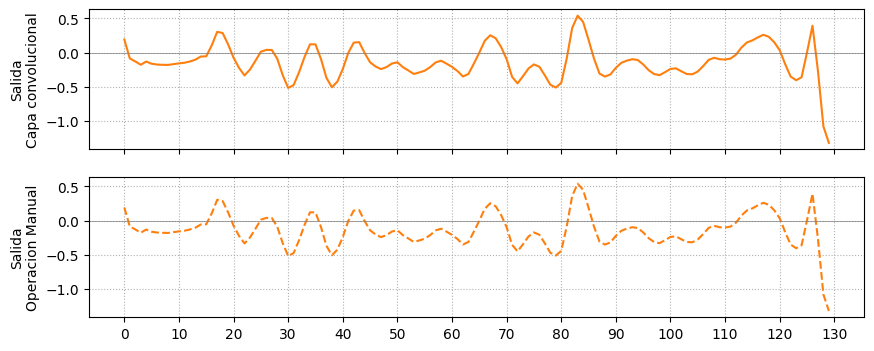

In [37]:
# Visualizar si salida manual coincide con generada desde red neuronal 
fig, ax = plt.subplots(2, 1, figsize = [10,4], squeeze = True, sharex = True)
ax[0].plot(salida_f1[:130], color = "C1")
ax[0].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
ax[0].set_ylabel("Salida\nCapa convolucional")
ax[0].grid(linestyle = ":")
ax[0].axhline(y = 0, linewidth = 0.5, color = "gray")
ax[1].plot(f[:130], linestyle = "--", color = "C1")
ax[1].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
ax[1].grid(linestyle = ":")
ax[1].set_ylabel("Salida\nOperacion Manual")
ax[1].axhline(y = 0, linewidth = 0.5, color = "gray")
plt.show()

La coincidencia es exacta y lo mismo ocurrirá si ejecutamos esta lógica con los demás filtros. Si gustas intentarlo, haslo.

### Ejercicio 4

Como puedes evidenciar, la convolución es un proceso de suavizamiento de la entrada original que nos permite contar con diferentes perspectivas de esta señal de audio. Lo anterior a fin de destacar características específicas del sonido. Notemos por ejemplo la relación existente entre la salida del filtro 1 con el surgimiento de los valles de dB (volúmenes de sonido bajos).

Lo anterior queda más claro cuando aplicamos la siguiente capa del modelo mejorado y que corresponde con la activación **ReLu** a las salidas convolucionales. Ejecuta esta operación en la salida del primer filtro. Puedes utilizar la salida propia del submodelo convolucional o la obtenida manualmente. Recuerda que la función ReLu, se define por la función $y = \max{(0,x)}$.

In [38]:
y_relu = np.maximum(0, f)

Contrasta visualmente el resultado obtenido con el sonido original.

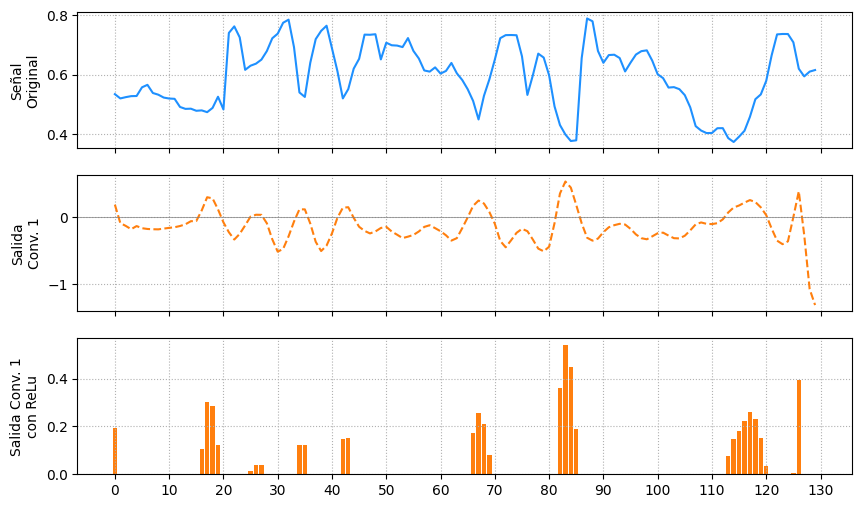

In [39]:
fig, ax = plt.subplots(3, 1, figsize = [10,6], squeeze = True, sharex = True)
ax[0].plot(sound_orig[:130], color = "dodgerblue")
ax[0].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
ax[0].set_ylabel("Señal\nOriginal")
ax[0].grid(linestyle = ":")
ax[1].plot(f[:130], linestyle = "--", color = "C1")
ax[1].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
ax[1].grid(linestyle = ":")
ax[1].set_ylabel("Salida\nConv. 1")
ax[1].axhline(y = 0, linewidth = 0.5, color = "gray")
ax[2].bar(height = y_relu[:130], x = range(len(y_relu[:130])), color = "C1")
ax[2].set_xticks(ticks = range(0,140,10), labels = range(0,140,10))
ax[2].grid(linestyle = ":")
ax[2].set_ylabel("Salida Conv. 1\ncon ReLu")
ax[2].axhline(y = 0, linewidth = 0.5, color = "gray")
plt.show()